<a href="https://colab.research.google.com/github/shawnfrancis578-collab/shawnfrancis578-collab.github.io/blob/main/Shawn_Practical_3_GenAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 3: Neural Language Models Using RNN, LSTM and GRU

**Name:** Shawn Francis  
**Aim:** To implement neural language models using Simple RNN, LSTM, and GRU for sequence modelling and next-token prediction.

## Theory
A neural language model learns patterns in a sequence of words and predicts the next word from the preceding words.

- **Simple RNN:** passes information from the previous time step to the next, but may struggle with long-term dependencies.
- **LSTM:** uses input, forget, and output gates to retain useful information for a longer period.
- **GRU:** uses update and reset gates. It is simpler than LSTM and generally trains faster.

In [1]:
!pip -q install tensorflow matplotlib

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

np.random.seed(42)
tf.random.set_seed(42)
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


## Step 1: Create the training corpus

In [3]:
text = '''
artificial intelligence is changing the world
artificial intelligence helps machines learn
machine learning is a branch of artificial intelligence
machine learning models learn from data
deep learning uses artificial neural networks
neural networks can recognize complex patterns
natural language processing helps computers understand language
language models can predict the next word
generative artificial intelligence can create new content
students learn artificial intelligence and machine learning
data science uses data to discover useful patterns
recurrent neural networks process sequential data
long short term memory learns long dependencies
gated recurrent units are efficient sequence models
technology makes human life easier
'''

lines = [line.strip() for line in text.lower().split('\n') if line.strip()]
print('Number of sentences:', len(lines))
for line in lines:
    print(line)

Number of sentences: 15
artificial intelligence is changing the world
artificial intelligence helps machines learn
machine learning is a branch of artificial intelligence
machine learning models learn from data
deep learning uses artificial neural networks
neural networks can recognize complex patterns
natural language processing helps computers understand language
language models can predict the next word
generative artificial intelligence can create new content
students learn artificial intelligence and machine learning
data science uses data to discover useful patterns
recurrent neural networks process sequential data
long short term memory learns long dependencies
gated recurrent units are efficient sequence models
technology makes human life easier


## Step 2: Tokenize the text and generate n-gram sequences
For every sentence, progressively longer word sequences are created. The preceding words become the input and the final word becomes the target.

In [4]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(lines)
total_words = len(tokenizer.word_index) + 1

input_sequences = []
for line in lines:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for index in range(1, len(token_list)):
        input_sequences.append(token_list[:index + 1])

max_sequence_length = max(len(sequence) for sequence in input_sequences)
input_sequences = pad_sequences(
    input_sequences, maxlen=max_sequence_length, padding='pre'
)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print('Vocabulary size:', total_words)
print('Number of training sequences:', len(input_sequences))
print('Maximum sequence length:', max_sequence_length)
print('Shape of X:', X.shape)
print('Shape of y:', y.shape)

Vocabulary size: 63
Number of training sequences: 83
Maximum sequence length: 8
Shape of X: (83, 7)
Shape of y: (83,)


## Step 3: Define RNN, LSTM, and GRU models

In [5]:
def build_language_model(recurrent_layer):
    model = Sequential([
        tf.keras.Input(shape=(max_sequence_length - 1,)),
        Embedding(input_dim=total_words, output_dim=32),
        recurrent_layer(64),
        Dense(total_words, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

rnn_model = build_language_model(SimpleRNN)
lstm_model = build_language_model(LSTM)
gru_model = build_language_model(GRU)

print('RNN parameters:', rnn_model.count_params())
print('LSTM parameters:', lstm_model.count_params())
print('GRU parameters:', gru_model.count_params())

RNN parameters: 12319
LSTM parameters: 30943
GRU parameters: 24927


## Step 4: Train all three models

In [6]:
EPOCHS = 100

print('Training Simple RNN...')
rnn_history = rnn_model.fit(X, y, epochs=EPOCHS, verbose=0)
print('Simple RNN training completed.')

print('Training LSTM...')
lstm_history = lstm_model.fit(X, y, epochs=EPOCHS, verbose=0)
print('LSTM training completed.')

print('Training GRU...')
gru_history = gru_model.fit(X, y, epochs=EPOCHS, verbose=0)
print('GRU training completed.')

print(f'Final RNN loss:  {rnn_history.history["loss"][-1]:.4f}')
print(f'Final LSTM loss: {lstm_history.history["loss"][-1]:.4f}')
print(f'Final GRU loss:  {gru_history.history["loss"][-1]:.4f}')

Training Simple RNN...
Simple RNN training completed.
Training LSTM...
LSTM training completed.
Training GRU...
GRU training completed.
Final RNN loss:  0.3230
Final LSTM loss: 1.0074
Final GRU loss:  0.4858


## Step 5: Compare training loss

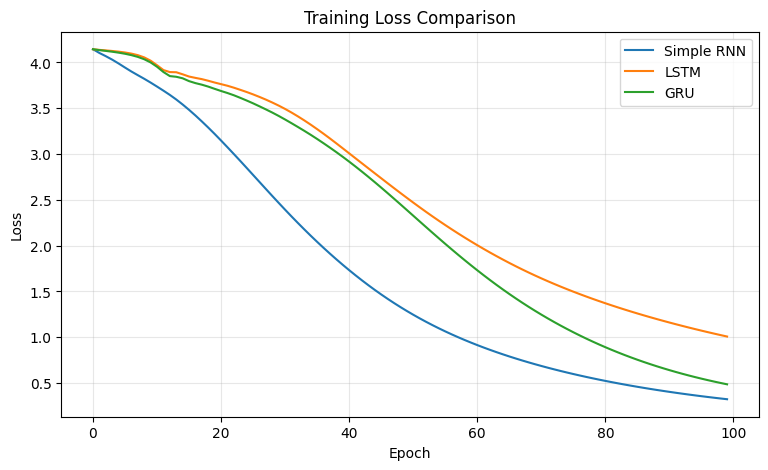

In [7]:
plt.figure(figsize=(9, 5))
plt.plot(rnn_history.history['loss'], label='Simple RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.title('Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Step 6: Predict the next words

In [8]:
def generate_text(model, seed_text, number_of_words=3):
    generated_text = seed_text.lower()

    for _ in range(number_of_words):
        sequence = tokenizer.texts_to_sequences([generated_text])[0]
        sequence = pad_sequences(
            [sequence], maxlen=max_sequence_length - 1, padding='pre'
        )
        probabilities = model.predict(sequence, verbose=0)[0]
        predicted_index = int(np.argmax(probabilities))
        predicted_word = tokenizer.index_word.get(predicted_index)

        if predicted_word is None:
            break
        generated_text += ' ' + predicted_word

    return generated_text

test_inputs = ['artificial intelligence', 'machine learning', 'language models']
for seed in test_inputs:
    print(f'\nInput: {seed}')
    print('RNN prediction: ', generate_text(rnn_model, seed))
    print('LSTM prediction:', generate_text(lstm_model, seed))
    print('GRU prediction: ', generate_text(gru_model, seed))


Input: artificial intelligence
RNN prediction:  artificial intelligence is changing the
LSTM prediction: artificial intelligence can machines the
GRU prediction:  artificial intelligence is changing the

Input: machine learning
RNN prediction:  machine learning models learn from
LSTM prediction: machine learning learning learn data
GRU prediction:  machine learning models learn from

Input: language models
RNN prediction:  language models can predict the
LSTM prediction: language models can predict the
GRU prediction:  language models can predict the


## Optional: Enter your own text

In [10]:
user_text = input('Enter starting words: ')
print('RNN prediction: ', generate_text(rnn_model, user_text))
print('LSTM prediction:', generate_text(lstm_model, user_text))
print('GRU prediction: ', generate_text(gru_model, user_text))

Enter starting words: Artificial Intelligence
RNN prediction:  artificial intelligence is changing the
LSTM prediction: artificial intelligence can machines the
GRU prediction:  artificial intelligence is changing the


## Result
Simple RNN, LSTM, and GRU language models were trained on token sequences. Their training losses were compared, and each model generated predicted words from a supplied starting phrase.

## Conclusion
Thus, neural language models using Simple RNN, LSTM, and GRU were successfully implemented for sequence modelling and next-token prediction. LSTM and GRU use gating mechanisms to handle sequential dependencies more effectively than a basic RNN.